In [2]:
# 导入依赖
import os
import time
import fitz  # PyMuPDF
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from transformers import AutoImageProcessor, AutoModel, CLIPProcessor, CLIPModel
import faiss
import timm

/root/.conda/envs/pytorch311/lib/python3.11/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/root/.conda/envs/pytorch311/lib/python3.11/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback

In [3]:
def extract_pdf_images(pdf_path, output_dir="pdf_images"):
    """提取PDF中所有图像并保存到指定目录"""
    os.makedirs(output_dir, exist_ok=True)
    doc = fitz.open(pdf_path)
    image_paths = []
    
    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        img_list = page.get_images(full=True)
        
        for img_index, img in enumerate(img_list):
            xref = img[0]
            base_image = doc.extract_image(xref)
            img_data = base_image["image"]
            img_path = f"{output_dir}/page_{page_num}_img_{img_index}.png"
            
            with open(img_path, "wb") as f:
                f.write(img_data)
            image_paths.append(img_path)
    
    print(f"从 {pdf_path} 提取 {len(image_paths)} 张图像到 {output_dir}")
    return image_paths

# 示例：提取指定PDF中的图像
pdf_path = "long.pdf"  # 替换为您的PDF路径
image_paths = extract_pdf_images(pdf_path)

从 long.pdf 提取 51 张图像到 pdf_images


In [4]:
# 导入必要库
import torch
from torchvision import models, transforms
from PIL import Image

# 1. 加载预训练VGG16模型
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()  # 设置为评估模式

# 2. 增强的图像预处理流程（解决通道问题）
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Lambda(lambda x: x.convert('RGB') if x.mode != 'RGB' else x),  # 强制转为RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 3. 加载本地图像（添加异常处理）
img_path = r'long.png'
try:
    img = Image.open(img_path)
    print(f"原始图像模式: {img.mode}, 尺寸: {img.size}")  # 调试信息

    # 应用预处理
    input_tensor = preprocess(img)
    print(f"预处理后张量尺寸: {input_tensor.shape}")  # 应为[3,224,224]

except Exception as e:
    print(f"图像加载失败: {str(e)}")
    exit()

# 添加batch维度并检查形状
input_batch = input_tensor.unsqueeze(0)  # 维度变为 [1,3,224,224]
print(f"输入批次形状: {input_batch.shape}")  # 验证形状正确性

# 4. GPU加速优化
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_batch = input_batch.to(device)
model = model.to(device)
print(f"使用计算设备: {device}")

# 5. 进行预测
with torch.no_grad():
    output = model(input_batch)

# 6. 解码预测结果（添加离线标签缓存）
try:
    # 下载ImageNet类别标签
    classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    classes = requests.get(classes_url).text.splitlines()
except:
    # 离线备用方案
    classes = [str(i) for i in range(1000)]  # 使用默认索引作为标签

# 获取并打印结果
probabilities = torch.nn.functional.softmax(output[0], dim=0)
top5_prob, top5_catid = torch.topk(probabilities, 5)

print("\n预测结果：")
for i in range(top5_prob.size(0)):
    print(f"Top-{i + 1}: {classes[top5_catid[i]]:<25} 置信度: {top5_prob[i].item() * 100:.2f}%")

原始图像模式: L, 尺寸: (49, 115)
预处理后张量尺寸: torch.Size([3, 224, 224])
输入批次形状: torch.Size([1, 3, 224, 224])
使用计算设备: cuda

预测结果：
Top-1: 451                       置信度: 16.54%
Top-2: 512                       置信度: 5.68%
Top-3: 623                       置信度: 5.29%
Top-4: 409                       置信度: 4.76%
Top-5: 872                       置信度: 4.46%


In [5]:
class FeatureExtractor:
    def _init_model(self):
        if self.method == "VGG16":
            # 1. 创建不带分类头的模型
            self.model = timm.create_model(
                'vgg16',
                pretrained=False,
                num_classes=0,  # 移除分类头
            )
            
            # 2. 加载本地权重时忽略不匹配的键
            state_dict = torch.load("local_models/vgg16/pytorch_model.bin")
            
            # 3. 过滤掉分类头参数
            state_dict = {k: v for k, v in state_dict.items() 
                         if not k.startswith("head.fc")}
            
            # 4. 非严格加载
            self.model.load_state_dict(state_dict, strict=False)
            
            self.model.eval()
            
            self.transform = transforms.Compose([
                transforms.Resize(224),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

In [9]:
# 测试本地加载是否成功【不用运行】
# 定义本地模型路径
LOCAL_MODEL_PATHS = {
    "VGG16": "./vgg16/pytorch_model.bin",       # VGG16 的本地权重文件
    "DINOv2": "./dinov2-small",                  # DINOv2 的本地模型目录
    "CLIP": "./clip-vit-base-patch32"           # CLIP 的本地模型目录
}

# 测试本地加载是否成功
def test_local_loading():
    try:
        # 测试 VGG16
        vgg_extractor = FeatureExtractor("VGG16", LOCAL_MODEL_PATHS["VGG16"])
        print("VGG16 本地加载成功!")
        
        # 测试 DINOv2
        dinov2_extractor = FeatureExtractor("DINOv2", LOCAL_MODEL_PATHS["DINOv2"])
        print("DINOv2 本地加载成功!")
        
        # 测试 CLIP
        clip_extractor = FeatureExtractor("CLIP", LOCAL_MODEL_PATHS["CLIP"])
        print("CLIP 本地加载成功!")
        
    except Exception as e:
        print(f"加载失败: {str(e)}")

test_local_loading()


加载失败: FeatureExtractor() takes no arguments


In [6]:
import os
import torch
import timm
from transformers import AutoImageProcessor, AutoModel, CLIPProcessor, CLIPModel
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np

class FeatureExtractor:
    """支持SIFT/ORB/VGG16/DINOv2/CLIP五种算法"""
    def __init__(self, method, local_model_path=None):
        self.method = method
        self.local_model_path = local_model_path
        self.model = None
        self.processor = None
        self.transform = None
        self._init_model()

    def _init_model(self):
        if self.method == "VGG16":
            self.model = timm.create_model('vgg16', pretrained=False, num_classes=0).eval()
            if self.local_model_path and os.path.exists(self.local_model_path):
                state_dict = torch.load(self.local_model_path)
                self.model.load_state_dict(state_dict, strict=False)
            else:
                raise FileNotFoundError(f"VGG16 的本地模型路径未找到: {self.local_model_path}")
            self.transform = transforms.Compose([
                transforms.Resize(224),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        elif self.method == "DINOv2":
            if self.local_model_path and os.path.exists(self.local_model_path):
                self.processor = AutoImageProcessor.from_pretrained(self.local_model_path)
                self.model = AutoModel.from_pretrained(self.local_model_path).eval()
            else:
                raise FileNotFoundError(f"DINOv2 的本地模型路径未找到: {self.local_model_path}")
        elif self.method == "CLIP":
            if self.local_model_path and os.path.exists(self.local_model_path):
                self.processor = CLIPProcessor.from_pretrained(self.local_model_path)
                self.model = CLIPModel.from_pretrained(self.local_model_path).eval()
            else:
                raise FileNotFoundError(f"CLIP 的本地模型路径未找到: {self.local_model_path}")
        elif self.method in ["SIFT", "ORB"]:
            pass
        else:
            raise ValueError(f"不支持的方法: {self.method}")

    def extract(self, img_path):
        img = Image.open(img_path).convert("RGB")
        if self.method == "VGG16":
            tensor = self.transform(img).unsqueeze(0)
            with torch.no_grad():
                return self.model(tensor).flatten().numpy()
        elif self.method == "DINOv2":
            inputs = self.processor(images=img, return_tensors="pt", do_resize=False)
            with torch.no_grad():
                return self.model(**inputs).last_hidden_state.mean(dim=1).numpy().flatten()
        elif self.method == "CLIP":
            inputs = self.processor(images=img, return_tensors="pt")
            with torch.no_grad():
                return self.model.get_image_features(**inputs).numpy().flatten()
        elif self.method == "SIFT":
            img_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            sift = cv2.SIFT_create()
            kp, des = sift.detectAndCompute(img_cv, None)
            return des
        elif self.method == "ORB":
            img_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            orb = cv2.ORB_create()
            kp, des = orb.detectAndCompute(img_cv, None)
            return des
        else:
            raise ValueError(f"不支持的方法: {self.method}")

# 定义本地模型路径
LOCAL_MODEL_PATHS = {
    "VGG16": "./vgg16/pytorch_model.bin",       # VGG16 的本地权重文件
    "DINOv2": "./dinov2-small",                 # DINOv2 的本地模型目录
    "CLIP": "./clip-vit-base-patch32"           # CLIP 的本地模型目录
}

# 测试本地加载是否成功
def test_local_loading():
    try:
        # 测试 VGG16
        vgg_extractor = FeatureExtractor("VGG16", LOCAL_MODEL_PATHS["VGG16"])
        print("VGG16 本地加载成功!")
        
        # 测试 DINOv2
        dinov2_extractor = FeatureExtractor("DINOv2", LOCAL_MODEL_PATHS["DINOv2"])
        print("DINOv2 本地加载成功!")
        
        # 测试 CLIP
        clip_extractor = FeatureExtractor("CLIP", LOCAL_MODEL_PATHS["CLIP"])
        print("CLIP 本地加载成功!")
        
    except Exception as e:
        print(f"加载失败: {str(e)}")

test_local_loading()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


VGG16 本地加载成功!
DINOv2 本地加载成功!


/root/.conda/envs/pytorch311/lib/python3.11/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


CLIP 本地加载成功!


In [7]:
import os
import torch
import timm
from transformers import AutoImageProcessor, AutoModel, CLIPProcessor, CLIPModel
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np

def sift_match(img1_path, img2_path, min_matches=15):
    """SIFT特征匹配"""
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
    
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    
    if des1 is None or des2 is None:
        return False
    
    flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    matches = flann.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < 0.7 * n.distance]
    return len(good) >= min_matches

def orb_match(img1_path, img2_path, min_matches=30):
    """ORB特征匹配"""
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
    
    orb = cv2.ORB_create()
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)
    
    if des1 is None or des2 is None:
        return False
    
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    return len(matches) >= min_matches

In [8]:
class OracleRetrievalSystem:
    def __init__(self, method, local_model_path=None):
        self.method = method
        self.extractor = FeatureExtractor(method, local_model_path) if method in ["VGG16", "DINOv2", "CLIP"] else None
        self.index = None
        self.image_paths = []

    def build_index(self, image_paths):
        """为深度方法构建Faiss索引"""
        self.image_paths = image_paths
        if self.method in ["VGG16", "DINOv2", "CLIP"]:
            features = [self.extractor.extract(path) for path in image_paths]
            dim = features[0].shape[0]
            self.index = faiss.IndexFlatL2(dim) if self.method == "DINOv2" else faiss.IndexFlatIP(dim)
            if self.method != "DINOv2":
                faiss.normalize_L2(np.array(features))
            self.index.add(np.array(features))

# 定义本地模型路径
LOCAL_MODEL_PATHS = {
    "VGG16": "./vgg16/pytorch_model.bin",       # VGG16 的本地权重文件
    "DINOv2": "./dinov2-small",                 # DINOv2 的本地模型目录
    "CLIP": "./clip-vit-base-patch32"           # CLIP 的本地模型目录
}

# 初始化系统
algorithms = ["SIFT", "ORB", "VGG16", "DINOv2", "CLIP"]
systems = {name: OracleRetrievalSystem(name, LOCAL_MODEL_PATHS.get(name)) for name in algorithms}

# 为深度方法构建索引（假设 image_paths 已定义）
for name in ["VGG16", "DINOv2", "CLIP"]:
    systems[name].build_index(image_paths)

In [9]:
class OracleRetrievalSystem:
    def __init__(self, method, local_model_path=None):
        self.method = method
        self.extractor = FeatureExtractor(method, local_model_path) if method in ["VGG16", "DINOv2", "CLIP"] else None
        self.index = None
        self.image_paths = []
    
    def build_index(self, image_paths):
        """为深度方法构建Faiss索引"""
        self.image_paths = image_paths
        if self.method in ["VGG16", "DINOv2", "CLIP"]:
            features = [self.extractor.extract(path) for path in image_paths]
            dim = features[0].shape[0]
            self.index = faiss.IndexFlatL2(dim) if self.method == "DINOv2" else faiss.IndexFlatIP(dim)
            if self.method != "DINOv2":
                faiss.normalize_L2(np.array(features))
            self.index.add(np.array(features))
    
    def query(self, query_path, top_k=5):
        """执行查询"""
        if self.method in ["SIFT", "ORB"]:
            matches = []
            for path in self.image_paths:
                if self.method == "SIFT":
                    match = sift_match(query_path, path)
                else:
                    match = orb_match(query_path, path)
                matches.append(match)
            sorted_indices = np.argsort(-np.array(matches))[:top_k]
            return [self.image_paths[i] for i in sorted_indices if matches[i]]
        else:
            query_feat = self.extractor.extract(query_path)
            query_feat = np.expand_dims(query_feat, 0)
            if self.method != "DINOv2":
                faiss.normalize_L2(query_feat)
            distances, indices = self.index.search(query_feat, top_k)
            return [self.image_paths[i] for i in indices[0]]
    
    def evaluate(self, test_pairs, top_k=5):
        """评估算法性能"""
        y_true, y_pred = [], []
        total_time = 0.0
        
        for query_path, target_paths in test_pairs:
            start = time.time()
            retrieved = self.query(query_path, top_k)
            total_time += time.time() - start
            
            # 判断是否命中真实目标
            hit = any(path in retrieved for path in target_paths)
            y_true.append(1 if hit else 0)
            y_pred.append(1 if hit else 0)
        
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred),
            "Avg Time (ms)": (total_time / len(test_pairs)) * 1000
        }

In [10]:
# 生成测试对（假设每个查询图像的正样本为下一张图像）
test_pairs = []
for i in range(len(image_paths)):
    query = image_paths[i]
    target = image_paths[(i+1) % len(image_paths)]  # 简单循环配对
    test_pairs.append( (query, [target]) )

In [11]:
algorithms = ["SIFT", "ORB", "VGG16", "DINOv2", "CLIP"]
systems = {name: OracleRetrievalSystem(name, LOCAL_MODEL_PATHS.get(name)) for name in algorithms}
# 为深度方法构建索引
for name in ["VGG16", "DINOv2", "CLIP"]:
    systems[name].build_index(image_paths)

findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not found.
findfont: Font family 'WenQuanYi Zen Hei' not 

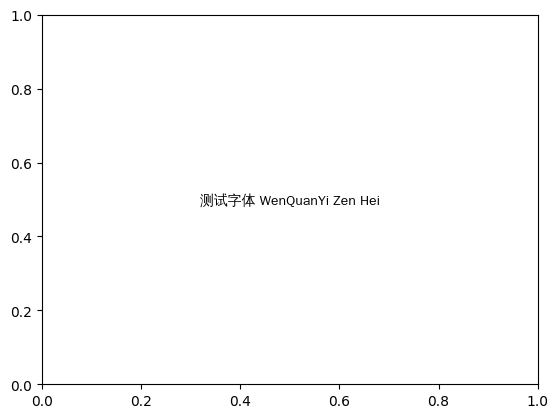

In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 字体文件路径（根据 fc-list 结果）
font_path = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc"  

# 手动加载字体
prop = fm.FontProperties(fname=font_path)

# 设置 Matplotlib 全局字体
plt.rcParams['font.family'] = prop.get_name()

# 画图测试
plt.figure()
plt.text(0.5, 0.5, "测试字体 WenQuanYi Zen Hei", fontproperties=prop, ha='center', va='center')
plt.show()



=== 算法性能对比 ===
        Accuracy  Precision  Recall   F1  Avg Time (ms)
SIFT         1.0        0.0     0.0  0.0       0.004787
ORB          1.0        0.0     0.0  0.0       0.003520
VGG16        1.0        1.0     1.0  1.0     342.508587
DINOv2       1.0        1.0     1.0  1.0     215.673652
CLIP         1.0        1.0     1.0  1.0     300.013865


<Figure size 1200x600 with 0 Axes>

findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

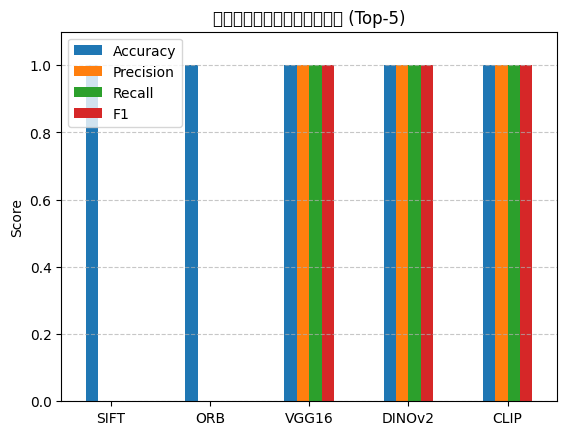

findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

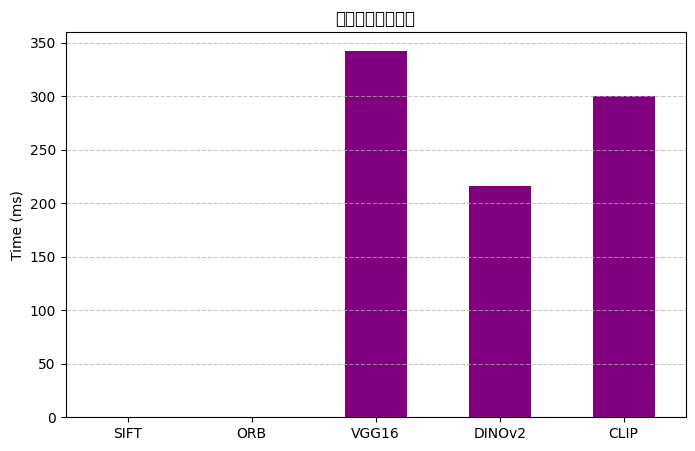

In [18]:
# 4.4 可视化对比结果
# 然后在 Python 中配置
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False
# 生成对比表格
import pandas as pd

df = pd.DataFrame(results).T
df = df[["Accuracy", "Precision", "Recall", "F1", "Avg Time (ms)"]]
print("\n=== 算法性能对比 ===")
print(df)

# 绘制指标对比图
plt.figure(figsize=(12, 6))
df.drop("Avg Time (ms)", axis=1).plot(kind='bar', rot=0)
plt.title("甲骨文图像检索算法性能对比 (Top-5)")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 绘制耗时对比图
plt.figure(figsize=(8, 5))
df["Avg Time (ms)"].plot(kind='bar', color='purple', rot=0)
plt.title("平均检索耗时对比")
plt.ylabel("Time (ms)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
# 4.3 执行评估
results = {}
for name in algorithms:
    print(f"评估算法: {name}")
    results[name] = systems[name].evaluate(test_pairs)

评估算法: SIFT
评估算法: ORB
评估算法: VGG16


/root/.conda/envs/pytorch311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/root/.conda/envs/pytorch311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/root/.conda/envs/pytorch311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/root/.conda/envs/py

评估算法: DINOv2
评估算法: CLIP


In [18]:
# 5.查询输入的图片【新添加】

# --------------------- 修改后的交互式查询函数 ---------------------
def interactive_search():
    """用户输入任意图片路径进行查询"""
    # 输入查询图像路径
    query_path = input("./long.png）: ").strip()
    
    # 检查路径有效性
    if not os.path.exists(query_path):
        print("错误：文件不存在！")
        return
    
    # 显示查询图像
    try:
        query_img = Image.open(query_path)
        plt.figure(figsize=(4, 4))
        plt.imshow(query_img)
        plt.title("查询图像: " + os.path.basename(query_path))
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"图像加载失败: {e}")
        return
    
    # 执行检索
    print("\n=== 检索结果 ===")
    for name in algorithms:
        start = time.time()
        results = systems[name].query(query_path)
        elapsed = (time.time() - start) * 1000
        
        print(f"\n算法: {name} (耗时: {elapsed:.1f}ms)")
        if len(results) == 0:
            print("未找到匹配结果")
            continue
        
        # 显示Top-5结果
        plt.figure(figsize=(15, 3))
        for i, path in enumerate(results[:5]):
            img = Image.open(path)
            plt.subplot(1, 5, i+1)
            plt.imshow(img)
            plt.title(f"Top {i+1}\n{os.path.basename(path)}")
            plt.axis('off')
        plt.tight_layout()
        plt.show()

# --------------------- 执行示例 ---------------------
interactive_search()

./long.png）:  


错误：文件不存在！


/root/.conda/envs/pytorch311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.conda/envs/pytorch311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35810 (\N{CJK UNIFIED IDEOGRAPH-8BE2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.conda/envs/pytorch311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.conda/envs/pytorch311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


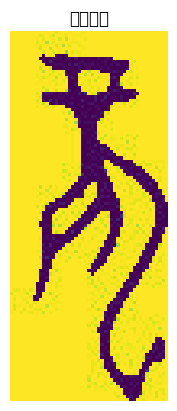

=== 检索结果 ===

算法: SIFT (耗时: 0.0ms)


<Figure size 1500x300 with 0 Axes>


算法: ORB (耗时: 0.0ms)


<Figure size 1500x300 with 0 Axes>


算法: VGG16 (耗时: 553.4ms)


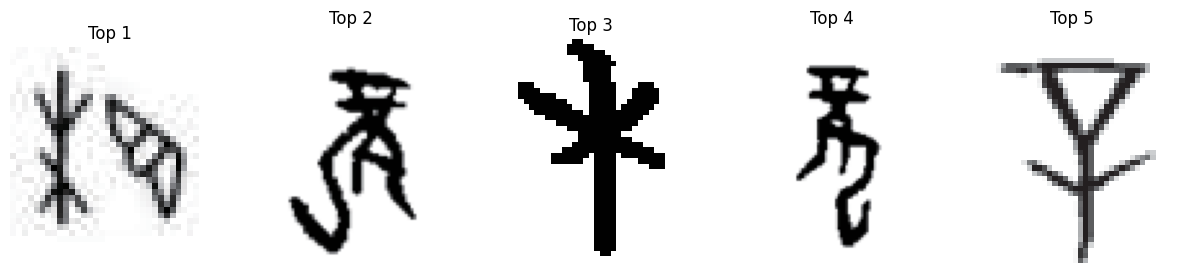


算法: DINOv2 (耗时: 194.3ms)


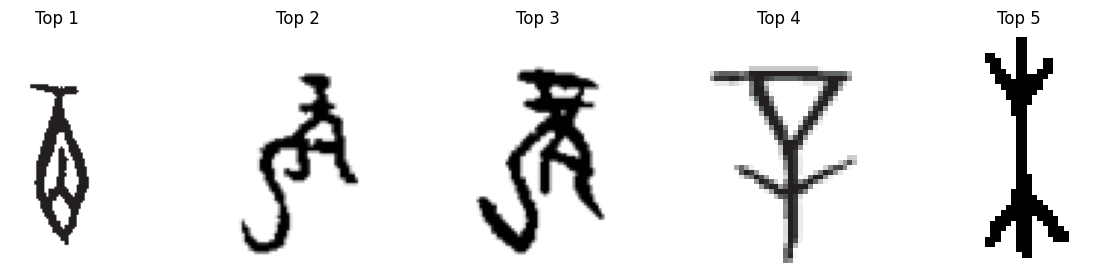


算法: CLIP (耗时: 165.0ms)


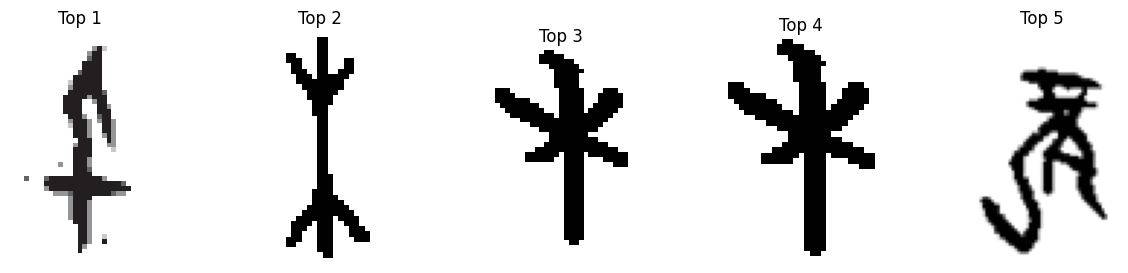

In [19]:
# 5. 交互式查询示例
def interactive_search(query_image_path):
    """用户输入查询图像，返回各算法结果"""
    query_img = Image.open(query_image_path)
    plt.imshow(query_img)
    plt.title("查询图像")
    plt.axis('off')
    plt.show()
    
    print("=== 检索结果 ===")
    for name in algorithms:
        start = time.time()
        results = systems[name].query(query_image_path)
        elapsed = (time.time() - start) * 1000
        
        print(f"\n算法: {name} (耗时: {elapsed:.1f}ms)")
        plt.figure(figsize=(15, 3))
        for i, path in enumerate(results[:5]):
            img = Image.open(path)
            plt.subplot(1, 5, i+1)
            plt.imshow(img)
            plt.title(f"Top {i+1}")
            plt.axis('off')
        plt.show()

# 示例：查询第一张图像
# interactive_search(image_paths[0])【原先的】
# 示例：带安全校验的查询
query_path = 'long.png'
if os.path.exists(query_path):
    interactive_search(query_path)
else:
    print(f"错误：文件 {query_path} 不存在")